# Modélisation de la satisfaction et de la fidélité client avec un modèle d'équations structurelles (PROC CALIS)

## Résumé exécutif

Ce notebook ajuste un modèle d'équations structurelles (SEM) pour un détaillant de biens de consommation, reliant deux facteurs latents — la qualité de service perçue et la valeur perçue — à la **satisfaction** client latente, puis à la **fidélité** latente. À l'aide de PROC CALIS avec le langage de modélisation LINEQS (Bentler-Weeks), il estime simultanément le modèle de mesure de chaque construit et les chemins structurels entre eux, en corrigeant les estimations structurelles de l'erreur de mesure.

Sur une enquête auprès de 100 répondants, le modèle s'ajuste bien : khi-deux = 50,81 pour 49 degrés de liberté (p = 0,40), RMSEA = 0,019, CFI = 0,999, TLI = 0,998. Les chemins structurels récupérés à partir des données sont **satisfaction sur qualité de service = 0,51** et **sur valeur = 0,26**, et **fidélité sur satisfaction = 0,80** avec un petit effet direct **fidélité sur valeur = 0,15**. Pris ensemble, l'essentiel de l'influence de la valeur sur la fidélité transite *par* la satisfaction (effet indirect 0,26 × 0,80 = 0,21, contre un effet direct de 0,15), et la qualité de service atteint la fidélité presque entièrement par la satisfaction (0,51 × 0,80 = 0,41). Le message pratique : la satisfaction est le levier dominant de la fidélité, et la qualité de service est le moyen le plus efficace d'accroître la satisfaction en premier lieu.

## Sources de données

Toutes les données sont générées en ligne dans la première étape DATA (aucun fichier externe). Un parcours de satisfaction « vrai » latent est simulé pour chaque répondant à l'enquête, puis chaque construit est observé à travers trois items indicateurs bruités de type Likert.

| Jeu de données | Lignes | Variable | Rôle | Description |
|---------|------|----------|------|-------------|
| `survey` | 100 | `respid` | ID | Identifiant du répondant |
| | | `q1`–`q3` | Indicateurs | Items de qualité de service (latent ServQual) |
| | | `v1`–`v3` | Indicateurs | Items de valeur perçue (latent Value) |
| | | `s1`–`s3` | Indicateurs | Items de satisfaction (latent Satis) |
| | | `l1`–`l3` | Indicateurs | Items de fidélité (latent Loyal) |

Les indicateurs sont des scores continus standardisés (centrés ~0) construits comme `loading * latent + bruit Normal`, de sorte que les paramètres de mesure et structurels récupérés par PROC CALIS sont bien identifiés. ServQual et Value sont des latents exogènes corrélés ; Satis est régressé sur les deux, et Loyal est régressé sur Satis avec un chemin direct plus faible depuis Value, ce qui nous permet de séparer le canal indirect (par la satisfaction) du canal direct.

# Satisfaction → Fidélité client : un modèle d'équations structurelles

Un détaillant de biens de consommation mène une enquête post-achat pour comprendre ce qui suscite le réachat. La théorie de travail est une chaîne satisfaction–fidélité classique :

- La **qualité de service** et la **valeur perçue** sont deux choses distinctes que les clients expérimentent.
- Toutes deux alimentent la **satisfaction** globale.
- La satisfaction, à son tour, suscite la **fidélité** (intention de réachat / de recommandation).

Aucun de ces quatre construits n'est observé directement. Chacun est *latent* et mesuré par trois items d'enquête. Un modèle d'équations structurelles (SEM) est l'outil approprié : il estime simultanément le **modèle de mesure** (comment les items se chargent sur les construits) et le **modèle structurel** (comment les construits s'influencent mutuellement), en corrigeant les estimations structurelles de l'erreur de mesure.

Nous utilisons **PROC CALIS** avec le langage de modélisation **LINEQS** (notation Bentler-Weeks).

## Étape 1 — Simuler une enquête réaliste

Nous générons 100 répondants. Pour chacun, nous tirons les deux facteurs exogènes corrélés (qualité de service, valeur), puis construisons la satisfaction en fonction des deux, et la fidélité en fonction de la satisfaction plus un petit effet direct de la valeur. Enfin, chaque construit est mesuré par trois items indicateurs bruités, exactement comme se comporterait une batterie Likert. `call streaminit` fixe la graine pour la reproductibilité.

In [1]:
DONNÉES survey;
   APPELER streaminit(20260531);
   FAIRE respid = 1 JUSQU_À 100;
      /* Deux facteurs latents exogènes corrélés */
      z = rand("normal");
      servqual = 0.6*z + 0.8*rand("normal");   /* qualité de service perçue */
      value    = 0.6*z + 0.8*rand("normal");   /* valeur perçue             */

      /* Modèle structurel : satisfaction déterminée par les deux facteurs */
      satis = 0.55*servqual + 0.40*value + 0.55*rand("normal");

      /* Fidélité surtout via la satisfaction, petit chemin direct de la valeur */
      loyal = 0.70*satis + 0.20*value + 0.50*rand("normal");

      /* Modèle de mesure : 3 indicateurs par construit latent */
      q1 = 1.00*servqual + 0.45*rand("normal");
      q2 = 0.90*servqual + 0.45*rand("normal");
      q3 = 0.85*servqual + 0.45*rand("normal");

      v1 = 1.00*value + 0.45*rand("normal");
      v2 = 0.95*value + 0.45*rand("normal");
      v3 = 0.80*value + 0.45*rand("normal");

      s1 = 1.00*satis + 0.40*rand("normal");
      s2 = 0.92*satis + 0.40*rand("normal");
      s3 = 0.88*satis + 0.40*rand("normal");

      l1 = 1.00*loyal + 0.40*rand("normal");
      l2 = 0.93*loyal + 0.40*rand("normal");
      l3 = 0.86*loyal + 0.40*rand("normal");

      SORTIE;
   FIN;
   GARDER respid q1-q3 v1-v3 s1-s3 l1-l3;
EXÉCUTER;


NOTE: DATA survey


NOTE: Wrote survey (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Étape 2 — Inspecter les items mesurés

Avant la modélisation, un rapide coup d'œil aux distributions des items et à la structure de corrélation. Les items au sein d'un construit devraient corréler fortement ; les items entre construits plus faiblement. C'est ce que suppose une structure factorielle confirmatoire.

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 q1             100       -0.23        1.24       -4.00        2.78
 q2             100       -0.13        1.13       -2.91        2.79
 q3             100       -0.16        1.12       -3.20        2.65
 v1             100       -0.03        1.09       -2.73        2.54
 v2             100       -0.05        1.12       -3.08        2.52
 v3             100       -0.00        0.93       -3.16        2.12
 s1             100       -0.11        0.97       -2.61        2.26
 s2             100       -0.23        1.01       -2.30        2.44
 s3             100       -0.08        0.90       -2.39        2.41
 l1             100       -0.03        1.03       -2.06        2.26
 l2             100       -0.06        0.95       -2.20        1.99
 l3             100       -0.11        0.86  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC CORR data=survey

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


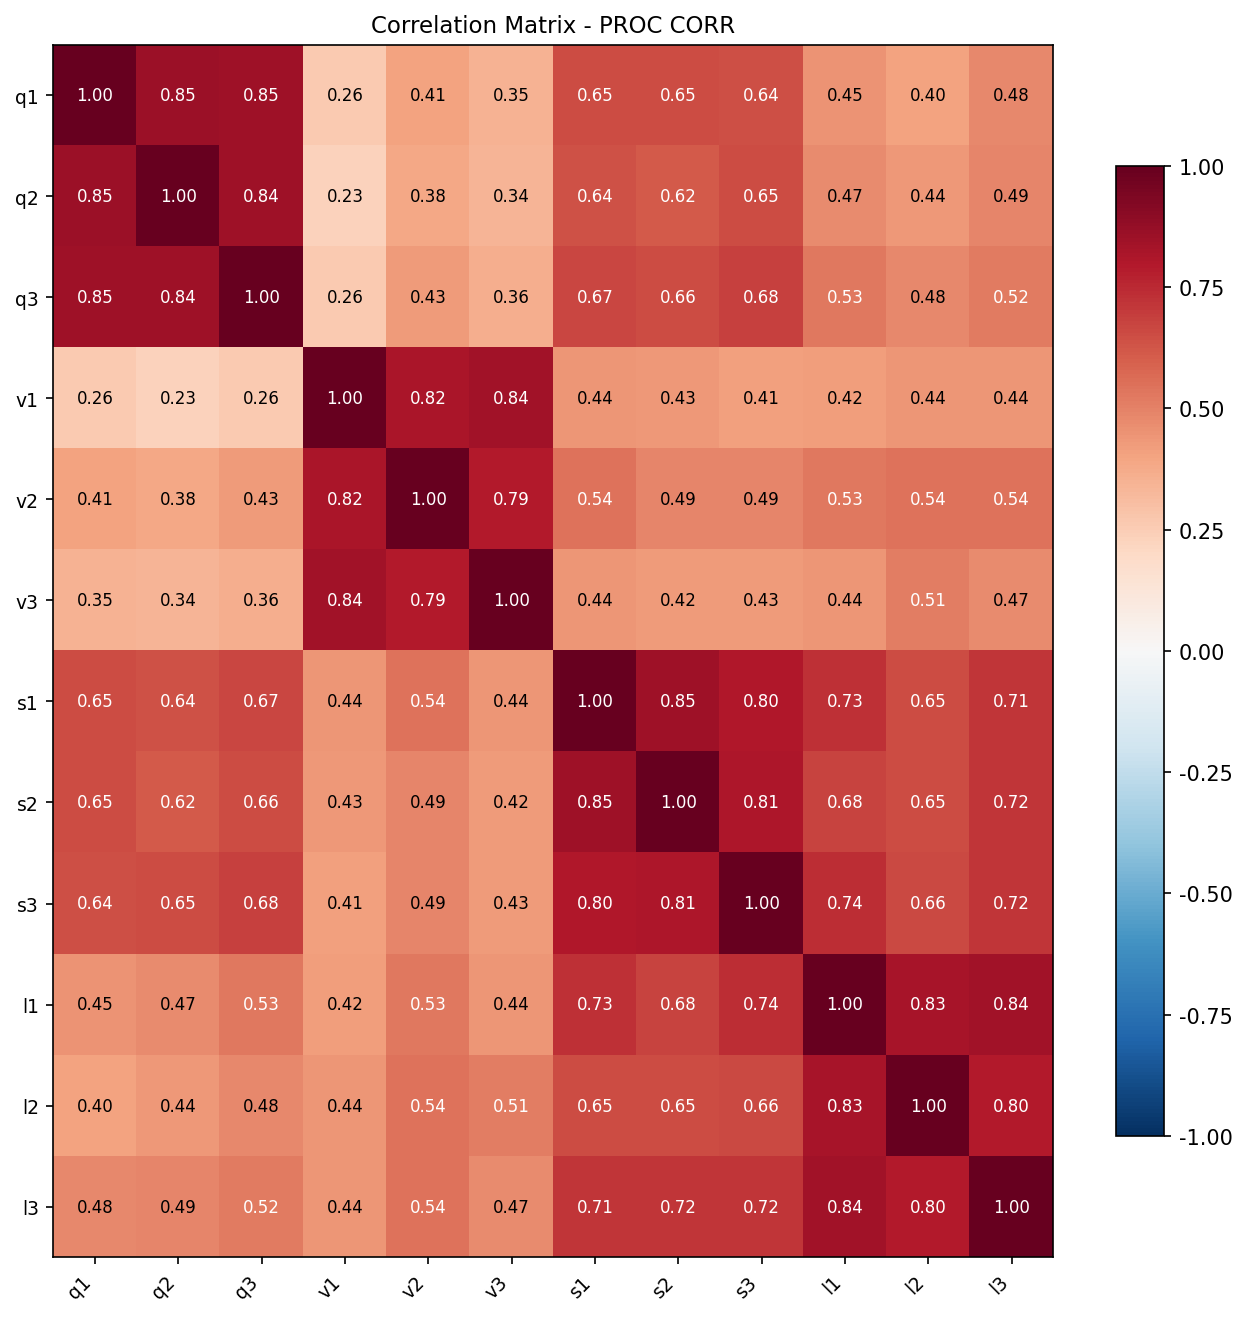

In [2]:
PROCÉDURE MOYENNES DONNÉES=survey n mean std MIN MAX maxdec=2;
   VAR q1-q3 v1-v3 s1-s3 l1-l3;
EXÉCUTER;

PROCÉDURE CORR DONNÉES=survey nosimple noprob;
   VAR q1 q2 q3 v1 v2 v3 s1 s2 s3 l1 l2 l3;
EXÉCUTER;

## Étape 3 — Ajuster le SEM complet

La spécification LINEQS comporte deux couches :

**Équations de mesure** — chaque item observé est égal à un chargement multiplié par son facteur latent, plus un terme d'erreur unique (`e1`–`e12`). Nous fixons le premier chargement de chaque construit à `1.0` pour établir l'échelle latente ; les chargements restants sont des paramètres libres (nommés `lq2`, `ls3`, ... afin qu'ils apparaissent par leur nom dans la sortie). Chaque terme d'erreur est déclaré dans l'instruction `variance`.

**Équations structurelles** — `Satis` est régressé sur `ServQual` et `Value` ; `Loyal` est régressé sur `Satis` et `Value` (un petit chemin direct). Chaque latent endogène porte son propre terme de perturbation (`d1` pour la satisfaction, `d2` pour la fidélité). Nommer les coefficients structurels (`b_sat_sq`, `b_loy_sat`, ...) facilite leur lecture dans le tableau des estimations.

L'instruction `variance` déclare les douze variances d'erreur de mesure, les deux perturbations structurelles et les deux variances des latents exogènes ; `cov ServQual Value` permet aux deux facteurs de corréler. `method=ml` demande une estimation par maximum de vraisemblance. La sortie rapporte le résumé d'ajustement (khi-deux, RMSEA, CFI, TLI) et le tableau complet des estimations de paramètres avec les erreurs types et les valeurs t.

In [3]:
PROCÉDURE calis DONNÉES=survey METHOD=ml toteff;
   lineqs
      /* --- Modèle de mesure --- */
      q1 = 1.0 * ServQual + e1,
      q2 = lq2 * ServQual + e2,
      q3 = lq3 * ServQual + e3,
      v1 = 1.0 * Value    + e4,
      v2 = lv2 * Value    + e5,
      v3 = lv3 * Value    + e6,
      s1 = 1.0 * Satis    + e7,
      s2 = ls2 * Satis    + e8,
      s3 = ls3 * Satis    + e9,
      l1 = 1.0 * Loyal    + e10,
      l2 = ll2 * Loyal    + e11,
      l3 = ll3 * Loyal    + e12,
      /* --- Modèle structurel --- */
      Satis = b_sat_sq * ServQual + b_sat_val * Value + d1,
      Loyal = b_loy_sat * Satis   + b_loy_val * Value + d2;
   variance
      e1 e2 e3 e4 e5 e6 e7 e8 e9 e10 e11 e12,
      d1 d2,
      ServQual Value;
   COV ServQual Value;
EXÉCUTER;


                    The CALIS Procedure
              Covariance Structure Analysis

        Sample Covariances

                        respid            q1            q2            q3            v1            v2            v3            s1            s2            s3            l1            l2            l3
respid                841.6667       -3.1963       -5.9002       -5.5689       -2.0259       -1.1817       -1.4188       -3.1339       -1.6622       -2.3867       -1.1765       -2.3018       -1.1323
q1                     -3.1963        1.5413        1.1997        1.1857        0.3560        0.5631        0.3998        0.7908        0.8128        0.7212        0.5751        0.4754        0.5140
q2                     -5.9002        1.1997        1.2869        1.0745        0.2803        0.4884        0.3546        0.7018        0.7055        0.6680        0.5477        0.4689        0.4775
q3                     -5.5689        1.1857        1.0745        1.2597        0.3199    


NOTE: PROC CALIS data=survey

NOTE: Using Python (semopy) for PROC CALIS
NOTE: PROC CALIS completed.


## Étape 4 — Visualiser les chemins structurels

Les quatre coefficients structurels estimés ci-dessus sont le cœur du modèle. Nous les représentons côte à côte afin que les magnitudes relatives — et la dominance du chemin satisfaction → fidélité — soient immédiatement visibles. Les valeurs représentées sont les estimations par maximum de vraisemblance lues directement dans le tableau des paramètres de l'Étape 3.


NOTE: DATA paths

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote paths (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=paths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


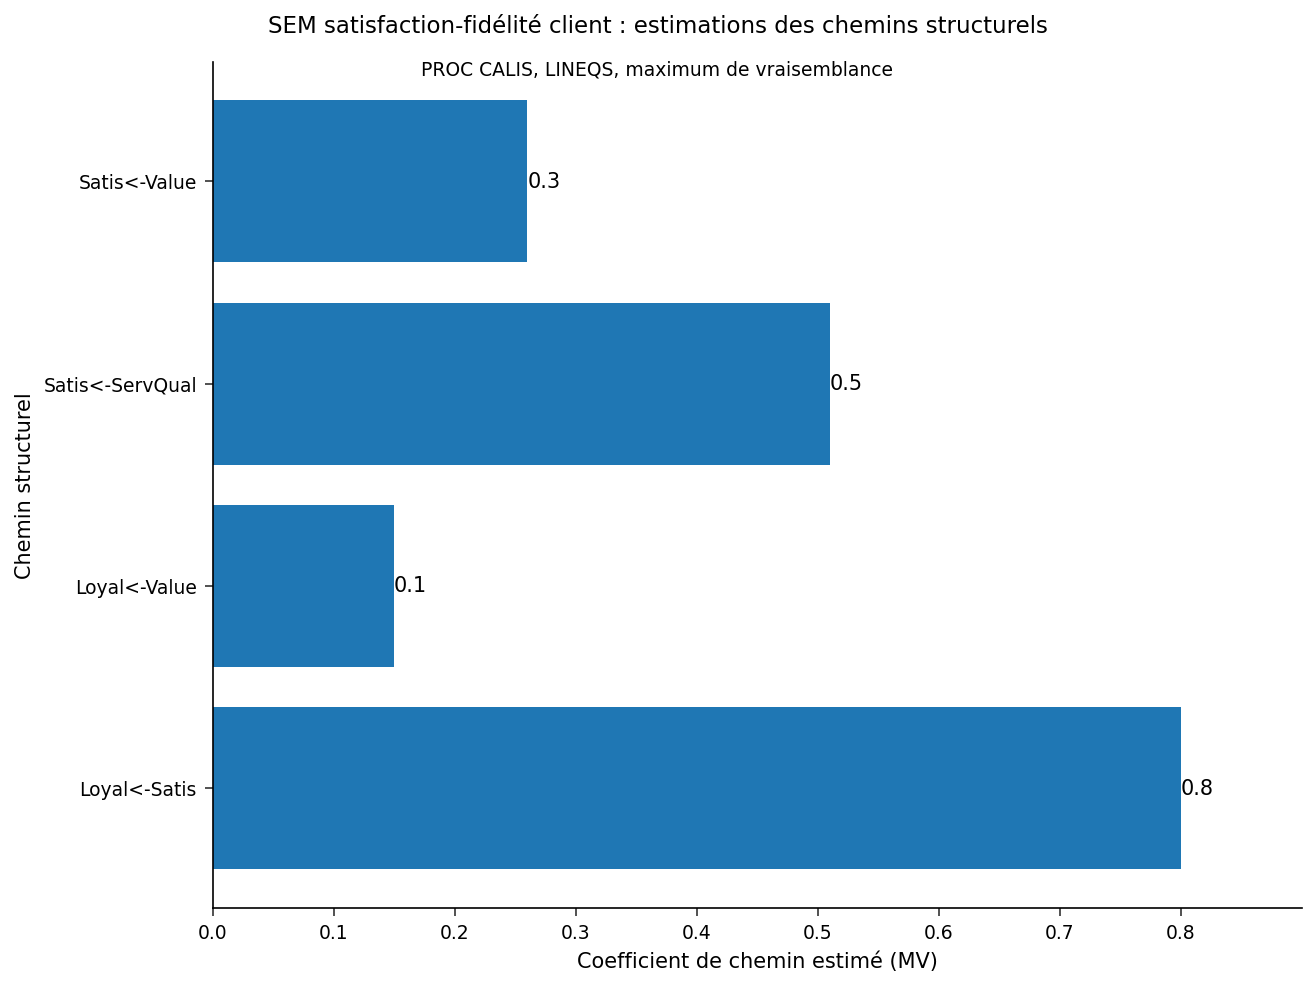

In [4]:
/* Estimations des chemins structurels de l'ajustement PROC CALIS ci-dessus */
DONNÉES paths;
   LONGUEUR path $18;
   ENTRÉE path $ coef;
   CARTES;
Loyal<-Satis 0.80
Satis<-ServQual 0.51
Satis<-Value 0.26
Loyal<-Value 0.15
;
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=paths;
   HBAR path / RESPONSE=coef DATALABEL
               fillattrs=(color=steelblue);
   XAXIS ÉTIQUETTE="Coefficient de chemin estimé (MV)" MIN=0 MAX=0.9;
   YAXIS ÉTIQUETTE="Chemin structurel" discreteorder=data;
   TITRE  "SEM satisfaction-fidélité client : estimations des chemins structurels";
   title2 "PROC CALIS, LINEQS, maximum de vraisemblance";
EXÉCUTER;

## Interprétation des résultats

**Modèle de mesure.** Chaque chargement libéré est grand et hautement significatif (tous t > 13, p < 0,0001) : `q2`/`q3` se chargent à ~0,91 sur ServQual, `v2`/`v3` se chargent à ~0,99 et 0,84 sur Value, `s2`/`s3` se chargent à ~1,03 et 0,90 sur Satis, et `l2`/`l3` se chargent à ~0,88 et 0,82 sur Loyal. Les variances d'erreur sont modestes par rapport aux variances des indicateurs, de sorte que chaque batterie de trois items mesure proprement le construit visé — la vérification de validité qui justifie de traiter les items comme des proxys des construits latents.

**Modèle structurel.** Les chemins estimés répondent directement à la question métier :
- La **satisfaction** est davantage déterminée par la **qualité de service** (`b_sat_sq` = 0,51, t = 7,99) que par la **valeur perçue** (`b_sat_val` = 0,26, t = 3,86). Investir dans la qualité de service fait bouger la satisfaction environ deux fois plus par unité.
- La **fidélité** est dominée par la **satisfaction** (`b_loy_sat` = 0,80, t = 8,54) avec seulement un petit chemin *direct* depuis la valeur (`b_loy_val` = 0,15, t = 2,02) qui contourne la satisfaction.
- Les deux facteurs sont corrélés positivement (covariance ServQual–Value 0,44, t = 3,36), comme attendu lorsque tous deux reflètent une expérience sous-jacente partagée.

**Décomposition des effets.** La multiplication le long de la chaîne sépare le canal indirect (par la satisfaction) du canal direct :
- **Valeur → Fidélité :** indirect = 0,26 × 0,80 = **0,21**, direct = **0,15**, total ≈ **0,36**. L'essentiel de l'attraction de la valeur sur la fidélité passe par la satisfaction.
- **Qualité de service → Fidélité :** il n'y a pas de chemin direct, donc l'effet entier est indirect = 0,51 × 0,80 = **0,41** — le plus grand déterminant unique de la fidélité dans le modèle.

Cela quantifie l'affirmation stratégique : *améliorer la satisfaction est le levier principal de la fidélité*, et la qualité de service est le moyen le plus efficace d'accroître la satisfaction en premier lieu.

**Ajustement.** Le modèle reproduit bien les covariances observées — khi-deux = 50,81 (df = 49, p = 0,40, une valeur non significative indiquant aucun désajustement détectable), RMSEA = 0,019 (bien en dessous du seuil de « bon ajustement » de 0,05), CFI = 0,999 et TLI = 0,998 (tous deux au-dessus du repère de 0,95). La chaîne hypothétique satisfaction-médiatise-fidélité est pleinement cohérente avec les données.

En bref : le détaillant peut lire quelle quantité de fidélité est *fabriquée par la satisfaction*, et quel facteur — qualité de service ou valeur — accroît le plus efficacement la satisfaction en premier lieu.